# Figure 5 — Gnocchi's GC bias comes from its regional adjustment, and from fitting that adjustment on the wrong population

Five panels, one argument. Each is written to `output/fig5{A..E}.pdf` as a standalone
vector file for assembly in Illustrator.

| | Claim | Quantity |
|---|---|---|
| **A** | The bias is *introduced by* the regional adjustment, not inherited from the context-only model | mean standardized rank vs GC, for $r\equiv1$ and for full Gnocchi |
| **B** | That adjustment's GC dependence is wholly non-CpG — and $r_{\mathrm{CpG}}\approx1$ is *correct*, because methylation already carries it in step 1 | $r_{\mathrm{eff}}=E_2/E_1$, decomposed by CpG status |
| **C** | The DNM training set is not the scored population: at high GC it is mostly coding or uncovered sequence | composition of the background training sites per GC bin |
| **D** | Restricting the training set to the scored population flattens the empirical DNM rate — and the fit then tracks it | fitted and empirical $P(\mathrm{DNM})$, non-CpG, three training populations |
| **E** | Refitting $r$ on the scored population removes the bias in Gnocchi itself | panel A's statistic, with the retrained Gnocchi added |

A and E are the same statistic on the same windows, so they are read as before/after.
B, C and D explain what happens in between.

In [1]:
%matplotlib inline
import os
import sys

import matplotlib.pyplot as plt
import numpy as np
import polars as pl

# Works whether the kernel's cwd is fig5/ (Jupyter's default) or the repo root.
_HERE = os.path.abspath("")
if os.path.basename(_HERE) != "fig5" and os.path.isdir(os.path.join(_HERE, "fig5")):
    _HERE = os.path.join(_HERE, "fig5")
_REPO_ROOT = os.path.dirname(_HERE)
for p in (_REPO_ROOT, _HERE):
    if p not in sys.path:
        sys.path.insert(0, p)

import config
import data as D
import depletion_rank as DR
import diagnostics as X
import panels

print("repo root:", _REPO_ROOT)

repo root: /Users/petermchale/gnomad_nc_constraint


## Configuration

**Two inputs are not in this repo** and must be supplied by hand. Both live in
**`fig5/config.py`**, not in the cell below, because `fig5/refit.py` reads them from
there too — see below for why that matters.

`DEPLETION_RANK_BED` — panel A's third curve. From the constraint-tools
`CONSTRAINT_TOOLS_DATA` path used by
`papers/neutral_models_are_biased/9.regression/experiment.1.ipynb`:

```
{CONSTRAINT_TOOLS_DATA}/depletion_rank_scores/41586_2022_4965_MOESM3_ESM.noncoding.enhancer.BGS.gBGC.GC_content.bed
```

Left `None`, panel A builds with two curves instead of three and prints a notice.

`GENEHANCER_BED` — the enhancer-exclusion half of McHale et al.'s "neutral" window
definition. GeneHancer is licensed and cannot be downloaded here. Left `None`,
*neutral* means noncoding + `pass_qc` + autosome/PAR throughout.

**Why this one is not just a notebook constant.** It defines the analyzed window set,
which is used in two separate processes: `refit.py -population scored` uses it to decide
which training sites survive the restriction (what the model is *fit* on), and this
notebook uses it to decide which windows the panels are *evaluated* on. If those
disagree, the model is trained on one population and scored on another — precisely the
defect this figure is about. Both read it from `fig5/config.py`, so they cannot
disagree within a run; and since refits persist on disk across edits, `refit.py` stamps
the value it used into `refits/provenance.json` and `data.refit_path` refuses a refit
built under a different setting. Change `config.py` and you get a loud error naming the
refit to rerun.

**Prerequisite.** Panels B, D and E read the three refits, which are produced by

```
.venv/bin/python fig5/refit.py -population full
.venv/bin/python fig5/refit.py -population scored
.venv/bin/python fig5/refit.py -population sizematched
```

(~6 min each), into the repo-root `refits/` — one copy of each table, also read
directly by `fig3/` and `dnm_training_size/`. `D.refit_path` raises with the exact
command if one is missing or was built under a different `GENEHANCER_BED`.

In [2]:
CACHE_DIR = os.path.join(_REPO_ROOT, "tmp")   # shared bucket-download cache
OUTPUT_DIR = D.OUTPUT_DIR                     # fig5/output
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Set these in fig5/config.py, NOT here -- fig5/refit.py reads them from there too.
DEPLETION_RANK_BED = config.DEPLETION_RANK_BED
GENEHANCER_BED = config.GENEHANCER_BED
print(f"DEPLETION_RANK_BED = {DEPLETION_RANK_BED!r}\nGENEHANCER_BED     = {GENEHANCER_BED!r}")

N_BINS = D.N_BINS           # 20
XRANGE = D.XRANGE           # (0.2, 0.73), visually matched to Fig. 2A
MIN_N_WINDOWS = 100         # drop GC bins holding fewer windows than this
MIN_N_SITES = 500           # ... or fewer training sites, in panels C and D
FIGSIZE = (7.0, 4.6)


def save(fig, letter):
    "One vector PDF per panel, for assembly in Illustrator. PNG alongside for review."
    for ext, kw in ((".pdf", {}), (".png", {"dpi": 200})):
        fig.savefig(os.path.join(OUTPUT_DIR, f"fig5{letter}{ext}"), bbox_inches="tight", **kw)
    print("wrote", os.path.join(OUTPUT_DIR, f"fig5{letter}.pdf"))

DEPLETION_RANK_BED = None
GENEHANCER_BED     = None


## Notation

Index 1 kb windows by $w$. Chen et al.'s model is a product of two factors. Write
$c=(t,m)$ for a *class* of possible SNV: trinucleotide context $t$ (32 of them) and
methylation level $m$. Let $n_c(w)$ be the number of gnomAD-callable sites of class $c$
in window $w$, and $p_c$ the fitted per-site mutation probability for that class
(`fitted_po`, keyed by $(t,\mathrm{ref},\mathrm{alt},m)$).

**Step 1 — sequence context and methylation only.**

$$E_1(w) \;=\; \sum_c n_c(w)\, p_c .$$

**Step 2 — the regional adjustment.** For each context $t$ a logistic regression is fit
on de novo mutations, then

$$r_t(w) \;=\; \frac{\sigma\!\big(\beta_{t0} + \boldsymbol\beta_t^{\!\top} \mathbf z_t(w)\big)}{\sigma(\beta_{t0})},
\qquad
E_2(w) \;=\; \sum_c n_c(w)\, p_c\, r_{t(c)}(w),$$

where $\mathbf z_t(w)$ is the standardized, PCA-transformed vector of regional features
at $w$ and $\sigma$ is the logistic function. Two consequences are used throughout:

1. $r$ is a **ratio of predicted probabilities**, so a *level* error in the fitted model
   — one common to numerator and denominator — cancels exactly and never reaches
   Gnocchi. Only feature-driven *variation* survives.
2. $r_t$ does **not** depend on methylation: there is one model per trinucleotide
   context, pooling all 16 methylation levels.

(The paper's Methods state $r=\boldsymbol\beta\cdot\mathbf x(w)\,/\,\boldsymbol\beta\cdot\bar{\mathbf x}$,
a ratio of *logits*. The code computes the ratio of probabilities above, and the code is
what produced the published scores.)

**The score.** With $O(w)$ the observed count of rare variants,

$$\chi^2_M(w)=\frac{\big(O(w)-E_M(w)\big)^2}{E_M(w)},
\qquad
z_M(w) = -\operatorname{sign}\!\big(O(w)-E_M(w)\big)\sqrt{\chi^2_M(w)}$$

for $M\in\{1,2\}$, keeping $|z|\le 10$ — so high $z$ means constrained. Standardizing to
a rank within the analyzed window set,

$$\rho_M(w)=\frac{\operatorname{rank}\big(z_M(w)\big)-\tfrac12}{n},$$

which is uniform on $(0,1)$ by construction. **Panels A and E plot
$\;\overline{\rho}_M(g)=\mathbb E\big[\rho_M(w)\,\big|\,w\in g\big]$** for GC bins $g$.
An unbiased metric sits at $0.5$ in every bin; departure from $0.5$ *is* the bias.

## Panel A — the bias is introduced by the regional adjustment

Both curves are computed on one window population, with the two $z$ statistics filtered
jointly and ranked *after* that filter, so they describe exactly the same windows. The
only difference between them is whether $r$ was applied.

Depletion rank is an independently constructed metric on **Halldorsson's own windows**,
so it is ranked within its own set and overlaid, never joined on `element_id`. That is
legitimate here precisely because $\rho$ is uniform on $(0,1)$ for every curve: what is
compared is how each metric's uniform mass redistributes across GC.

Summary statistic quoted in the text: $\;\overline{|\overline{\rho}_M(g)-0.5|}\;$ across bins.

In [3]:
df_win = D.window_table(CACHE_DIR, genehancer_bed=GENEHANCER_BED)
edges = D.gc_edges(df_win["GC_content"].to_numpy(), N_BINS)
print(f"analyzed window set: {df_win.height:,} windows, "
      f"GC {df_win['GC_content'].min():.3f}-{df_win['GC_content'].max():.3f}")

df_a, binned_a = D.rank_curves(df_win, min_n=MIN_N_WINDOWS)
gc_mean = float(df_a["GC_content"].mean())
binned_a

analyzed window set: 1,843,559 windows, GC 0.140-0.837


  1,840,310 windows after joint z filtering
  mean |rank - 0.5|  step1        = 0.093  (over bins with n >= 100)
  mean |rank - 0.5|  step2        = 0.212  (over bins with n >= 100)


gc_bin,n,gc_mid,mean_step1,se_step1,mean_step2,se_step2
i64,u32,f64,f64,f64,f64,f64
0,2,0.157,0.133854,0.073397,0.338234,0.31193
1,41,0.19678,0.346163,0.041601,0.457317,0.049759
2,1210,0.236177,0.333394,0.006788,0.285144,0.006944
3,23714,0.268477,0.377781,0.001677,0.306085,0.001576
4,127703,0.300542,0.41977,0.000756,0.354876,0.000711
…,…,…,…,…,…,…
15,993,0.676921,0.335248,0.008938,0.856879,0.007291
16,503,0.712757,0.283838,0.012123,0.867125,0.009655
17,256,0.747621,0.261728,0.016675,0.877301,0.013496


DEPLETION_RANK_BED is not set -- panel A gets two curves instead of three.


wrote /Users/petermchale/gnomad_nc_constraint/fig5/output/fig5A.pdf


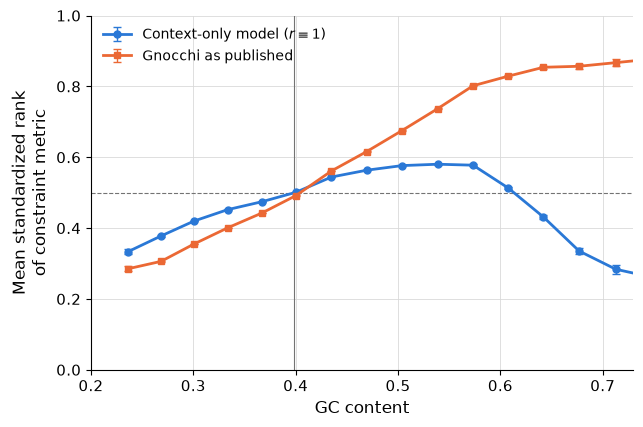

In [4]:
binned_dr = None
if DEPLETION_RANK_BED:
    binned_dr = DR.bin_depletion_rank(DR.load_depletion_rank_windows(DEPLETION_RANK_BED),
                                      n_bins=N_BINS)
else:
    print("DEPLETION_RANK_BED is not set -- panel A gets two curves instead of three.")

curves_a = [
    panels.curve_from_binned(binned_a, "step1", "step1", r"Context-only model ($r \equiv 1$)"),
    panels.curve_from_binned(binned_a, "step2", "step2", "Gnocchi as published"),
]
if binned_dr is not None:
    curves_a.append(panels.curve_from_binned(binned_dr, "dr", "dr",
                                             "Depletion rank (Halldorsson windows)"))

fig, ax = plt.subplots(figsize=FIGSIZE)
panels.panel_rank_bias(ax, curves_a, gc_mean=gc_mean, xrange=XRANGE, min_n=MIN_N_WINDOWS)
save(fig, "A")

## Panel B — the adjustment Gnocchi applies, decomposed by CpG status

The quantity actually applied to each window is the $E_1$-weighted mean of the
per-context $r$,

$$r_{\mathrm{eff}}(w)=\frac{E_2(w)}{E_1(w)}.$$

Aggregating a GC bin as a **ratio of summed expected counts** (not a mean of per-window
ratios — expected counts add, so this is the adjustment the bin actually receives), and
splitting the sum at CpG contexts $\mathcal K=\{\mathrm{ACG,CCG,GCG,TCG}\}$:

$$R_{\mathrm{eff}}(g)=\Pi(g)\,R_{\mathrm{CpG}}(g)+\big(1-\Pi(g)\big)\,R_{\mathrm{non}}(g),
\qquad \Pi(g)=\frac{\sum_{w\in g} E_1^{\mathcal K}(w)}{\sum_{w\in g} E_1(w)} .$$

This is an **exact identity**, not a fit, so the panel reads additively. The dashed grey
curve is the counterfactual $R_{\mathrm{non}}\equiv1$ with everything else untouched;
its flatness is the claim.

**Why $R_{\mathrm{CpG}}\approx1$ is correct, not a failure.** CpG mutability is dominated
by methylation, and $p_c$ is already keyed by methylation level — across methylation 0 to
15 the CpG C>T rate spans **3.0–4.3×** depending on context, the largest single rate
effect in the model, inside one trinucleotide. High-GC CpGs are CpG islands: **90–100%
hypomethylated above GC 0.70**, against ~2% in the GC bulk, and their empirical DNM rate
falls from 0.53 in the bulk to 0.19 in the top GC bin (**2.8×**). **Step 1 has already
applied that correction**,
via the covariation of GC content with methylation, so there is nothing left for $r$ to
adjust. (Chen et al. also strip `GC_content`, `CpG_island`, `Nucleosome`, `SINE` and
`met_sperm` from CpG-context models, so those models could not express a GC dependence
even if one were needed.) The GC trend in what Gnocchi applies is therefore entirely
non-CpG — which is where the rest of this figure looks.

reusing /Users/petermchale/gnomad_nc_constraint/fig5/output/r_eff_components.full.parquet


refit validation: max |r_eff(refit) - r_eff(published)| over 20 GC bins = 1.01e-04 (median 3.89e-06)


wrote /Users/petermchale/gnomad_nc_constraint/fig5/output/fig5B.pdf


gc_mid,n,pi_cpg,r_eff,r_cpg,r_non,r_counterfactual
f64,u32,f64,f64,f64,f64,f64
0.236184,1212,0.025077,0.956945,0.990545,0.956081,0.999763
0.268475,23729,0.029732,0.952518,0.991421,0.951325,0.999745
0.300542,127803,0.03723,0.960325,0.993222,0.959053,0.999748
0.333478,283824,0.046333,0.969429,0.993614,0.968254,0.999704
0.367076,382504,0.058685,0.980456,0.995619,0.97951,0.999743
…,…,…,…,…,…,…
0.607605,7652,0.219275,1.205363,0.997974,1.263611,0.999556
0.642128,2624,0.272455,1.291926,0.992815,1.403939,0.998042
0.676895,1000,0.330021,1.361819,0.988571,1.545676,0.996228


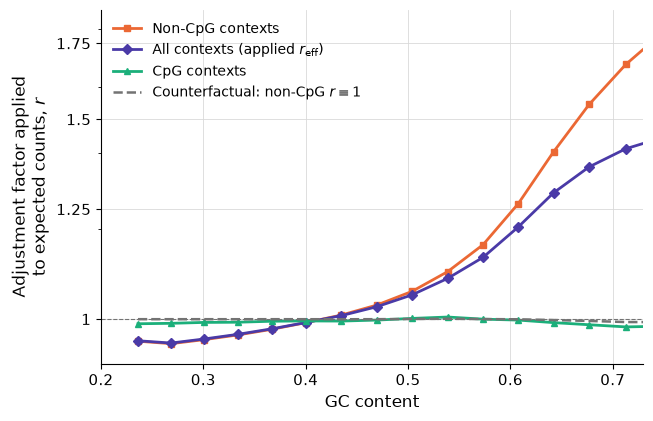

In [5]:
binned_b = D.r_eff_by_gc(df_win, edges, pop="full", cache_dir=CACHE_DIR)

fig, ax = plt.subplots(figsize=FIGSIZE)
panels.panel_r_eff(ax, binned_b, min_n=MIN_N_WINDOWS, xrange=XRANGE)
save(fig, "B")

binned_b.filter(pl.col("n") >= MIN_N_WINDOWS).select(
    ["gc_mid", "n", "pi_cpg", "r_eff", "r_cpg", "r_non", "r_counterfactual"])

## Panel C — the training set is not the scored population

$r$ is fit on de novo mutations and matched background sites drawn from the **whole
genome**, but applied to — and Gnocchi scored on — noncoding, `pass_qc`, autosome/PAR
windows. Panel C measures how far apart those two populations drift with GC.

Map each non-CpG background training site to its containing 1 kb tile and partition the
sites of GC bin $g$ three ways:

$$N(g)=N_{\mathrm{analyzed}}(g)+N_{\mathrm{coding}}(g)+N_{\mathrm{no\,cov}}(g),$$

where *analyzed* means the tile is in the scored population, *coding* that it is
annotated but coding or failing QC, and *no cov* that it has no row in the constraint
table at all. The stack plots the three fractions, which sum to 1 by construction
(asserted in code).

The fraction inside the scored population falls from ~0.83 in the GC bulk to under 0.30
by GC 0.68. So the model is fit on one population and applied to another, and the two
come apart exactly where panel A's bias is largest.

That matters because the excluded territory is not neutral filler, and the difference is
**not** mainly the coding part. Splitting non-CpG $P(\mathrm{DNM})$ by stratum (computed
below): the coding and noncoding rates are nearly equal and nearly flat in GC
(ratio 0.90–0.99 across the range), while the no-coverage stratum runs 1.55× the
noncoding rate in the GC bulk and **4.06× by GC 0.61**. Essentially all of the training
set's steep GC dependence is contributed by sequence gnomAD cannot call — which is also
where trio DNM calling is least reliable, so part of the excess is plausibly
false-positive DNM calls rather than real mutation.

reusing /Users/petermchale/gnomad_nc_constraint/fig5/output/dnm0_window_composition.20bins.parquet
dnm0 composition: 4,035,400 non-CpG background sites over 20 GC bins
wrote /Users/petermchale/gnomad_nc_constraint/fig5/output/fig5C.pdf


gc_mid,n_total,frac_analyzed,frac_coding,frac_noannot
f64,i64,f64,f64,f64
0.157425,10607,0.000189,0.0,0.999811
0.227125,2394,0.851713,0.015038,0.13325
0.261975,48110,0.902349,0.031594,0.066057
0.296825,265863,0.87439,0.050928,0.074681
0.331675,601255,0.856763,0.052943,0.090294
…,…,…,…,…
0.610475,23104,0.463729,0.356389,0.179882
0.645325,9815,0.352522,0.391136,0.256342
0.680175,3971,0.298162,0.432133,0.269705


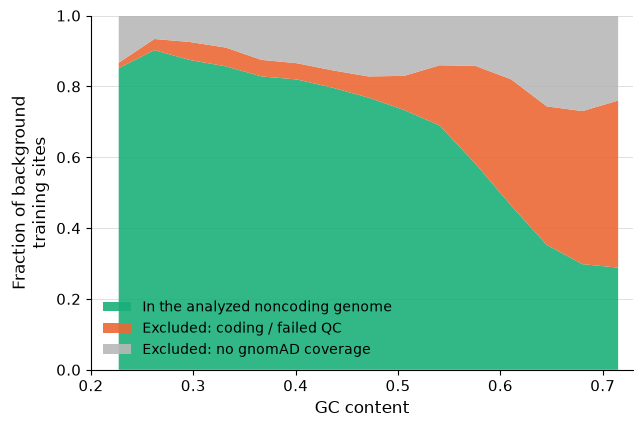

In [6]:
comp = D.dnm0_composition(edges, cache_dir=CACHE_DIR)

fig, ax = plt.subplots(figsize=FIGSIZE)
panels.panel_training_composition(ax, comp, min_n=MIN_N_SITES, xrange=XRANGE)
save(fig, "C")

comp.filter(pl.col("n_total") >= MIN_N_SITES).select(
    ["gc_mid", "n_total", "frac_analyzed", "frac_coding", "frac_noannot"])

## Panel D — restricting the training set flattens the DNM rate, and the fit can then track it

For each training population and each GC bin $g$, over non-CpG sites only:

$$\widehat p(g)=\frac{1}{|S_g|}\sum_{i\in S_g}\hat\pi_i \quad\text{(fitted)},
\qquad
\bar y(g)=\frac{1}{|S_g|}\sum_{i\in S_g} y_i \quad\text{(empirical)},$$

with $y_i\in\{0,1\}$ the DNM label and $\hat\pi_i$ the site's own fitted probability from
its own context's model, evaluated at the **site's** feature vector. Each pair is a
reliability diagram on its own population, so *fitted vs empirical within a pair* is the
comparison that means something.

Levels are not comparable **across** populations: the case-control ratio differs (12.2
vs 13.5 background sites per DNM), which shifts $P(\mathrm{DNM})$ for reasons unrelated
to GC. Each curve is therefore divided by its own site-weighted mean, leaving shape only.

Three populations:

* **original** — the training set as published;
* **scored** — restricted to the analyzed windows (the intervention);
* **size-matched** — the same *number* of sites as *scored*, drawn at random from the
  whole genome. This is the control that separates "better-matched population" from
  "less data", and it lies on top of the original pair.

Two things happen at once when the training set is restricted. The **empirical** GC
dependence itself shrinks and becomes monotone — on the original set $P(\mathrm{DNM})$
rises 2.4× and then *collapses* above GC 0.66; on the scored set it rises smoothly by
1.57× with no turnover. And the logistic regression can then actually fit it: on the
original set it misses by 26% and 29% *in opposite directions*, because it is a smooth
monotone surface chasing a curve that turns over.

This is why $R_{\mathrm{non}}$ in panel B is inflated — the model has partly learned a GC
slope that belongs to sequence outside the scored population.

**Caveat.** This panel measures a *level* error in $P(\mathrm{DNM})$, and levels cancel in
$r$. It diagnoses the fit; it is not itself a measurement of Gnocchi's bias. Panel E is.

full         non-CpG: 4,355,429 sites, 330,559 DNMs, 12.2 background per DNM


scored       non-CpG: 3,490,733 sites, 241,449 DNMs, 13.5 background per DNM


sizematched  non-CpG: 3,471,825 sites, 235,307 DNMs, 13.8 background per DNM


wrote /Users/petermchale/gnomad_nc_constraint/fig5/output/fig5D.pdf

full:
 gc_mid       n    n1  mean_pred  empirical_prop
24.9220    9884   726     0.0688          0.0735
28.3489  138720 10030     0.0695          0.0723
31.8810  539742 38988     0.0707          0.0722
35.6131  946096 69084     0.0724          0.0730
39.2875 1013622 74568     0.0745          0.0736
43.0823  777307 57987     0.0766          0.0746
46.9123  485577 37955     0.0795          0.0782
50.7157  243987 19903     0.0837          0.0816
54.5551  116776 10624     0.0895          0.0910
58.4293   51282  5770     0.0986          0.1125
62.2230   20091  2909     0.1120          0.1448
66.0771    7325  1296     0.1304          0.1769
70.0518    3073   449     0.1452          0.1461
73.8314    1237   150     0.1560          0.1213

scored:
 gc_mid      n    n1  mean_pred  empirical_prop
24.9320   8889   589     0.0677          0.0663
28.3409 122154  8357     0.0684          0.0684
31.8750 461298 31732     0.0688      

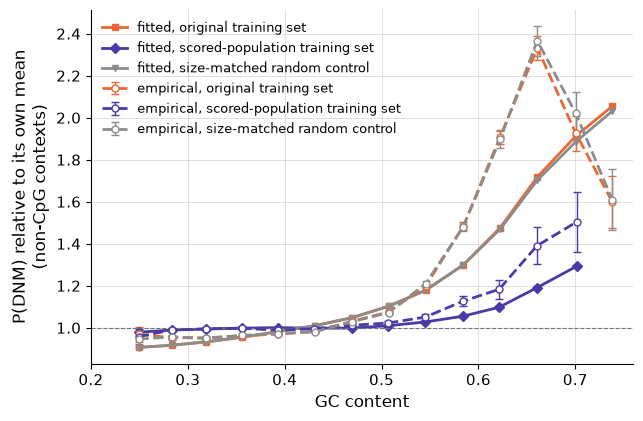

In [7]:
binned_d = D.dnm_probability(("full", "scored", "sizematched"), n_bins=N_BINS,
                             min_n=MIN_N_SITES)

fig, ax = plt.subplots(figsize=FIGSIZE)
panels.panel_dnm_probability_pairs(ax, binned_d, min_n=MIN_N_SITES, normalize=True)
save(fig, "D")

for pop, b in binned_d.items():
    print(f"\n{pop}:")
    print(b[["gc_mid", "n", "n1", "mean_pred", "empirical_prop"]].round(4).to_string(index=False))

## Panel E — refitting $r$ on the scored population removes Gnocchi's bias

Exactly one thing changes relative to the published pipeline: training sites outside the
analyzed window set are dropped. Everything downstream is identical — univariate
Bonferroni selection, standardization, `IncrementalPCA`, L1 logit per context,
genome-wide apply. So panel E is panel A's statistic with a third expected count,
$E_2^{\mathrm{scored}}$, added to the same joint $z$ filter and the same ranking.

Two controls make this a result rather than an anecdote, and both are printed below
rather than plotted (a curve indistinguishable from published Gnocchi is clutter):

* the **full-population refit** through this same code lands on published Gnocchi, so
  "before" and "after" differ by the intervention and not by whose code produced them;
* the **size-matched random refit** also lands on published Gnocchi, so the improvement
  is about *which* sites, not *how many*.

Note the retrained curve is expected to end up *better than* the context-only model, not
merely closer to it: a correct $r$ should repair the context-only model's own droop at
both GC extremes. That is the sense in which this is a positive result and not just the
removal of a defect.

  1,840,165 windows after joint z filtering
  mean |rank - 0.5|  step1        = 0.093  (over bins with n >= 100)
  mean |rank - 0.5|  step2        = 0.212  (over bins with n >= 100)
  mean |rank - 0.5|  scored       = 0.046  (over bins with n >= 100)
  mean |rank - 0.5|  full_refit   = 0.212  (over bins with n >= 100)
  mean |rank - 0.5|  sizematched  = 0.210  (over bins with n >= 100)
wrote /Users/petermchale/gnomad_nc_constraint/fig5/output/fig5E.pdf


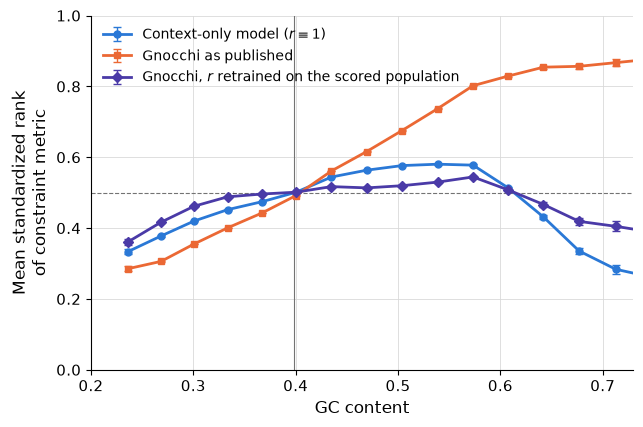

In [8]:
extra = [("scored", D.refit_path("expected", "scored"))]
CONTROLS = [("full_refit", "full"), ("sizematched", "sizematched")]
for label, pop in CONTROLS:
    extra.append((label, D.refit_path("expected", pop)))

df_e, binned_e = D.rank_curves(df_win, extra=extra, min_n=MIN_N_WINDOWS)

curves_e = [
    panels.curve_from_binned(binned_e, "step1", "step1", r"Context-only model ($r \equiv 1$)"),
    panels.curve_from_binned(binned_e, "step2", "step2", "Gnocchi as published"),
    panels.curve_from_binned(binned_e, "scored", "scored",
                             "Gnocchi, $r$ retrained on the scored population"),
]

fig, ax = plt.subplots(figsize=FIGSIZE)
panels.panel_rank_bias(ax, curves_e, gc_mean=float(df_e["GC_content"].mean()),
                       xrange=XRANGE, min_n=MIN_N_WINDOWS)
save(fig, "E")

## Claims the text makes but does not plot

Panels B and C each rest on a measurement that is stated in their markdown rather than
drawn. `diagnostics.py` computes all three, so nothing in the caption is unverifiable.

**Panel C.** Non-CpG $P(\mathrm{DNM})$ split by where the training site sits relative to
the scored population. Note the stratum definition here is about the *sequence* — coding
vs noncoding vs uncallable — so `noncoding` means `coding_prop = 0` regardless of QC,
which is deliberately not identical to panel C's `analyzed` category.

**Panel B.** The methylation effect step 1 already absorbs, and the CpG-island character
of high-GC CpGs. Together these are why $r_{\mathrm{CpG}}\approx1$ is the *correct*
behaviour rather than a failure: the large, strongly GC-dependent CpG effect has already
been applied upstream, so there is nothing left for the regional adjustment to correct.

In [9]:
st = X.dnm_rate_by_stratum(edges)
wide = (st.filter(pl.col("n") >= 2000)
          .pivot(values="p", index="gc_bin", on="stratum", aggregate_function="first")
          .join(st.filter(pl.col("stratum") == "noncoding").select(["gc_bin", "gc_pct"]),
                on="gc_bin")
          .drop_nulls().sort("gc_bin")
          .with_columns([(pl.col("coding") / pl.col("noncoding")).alias("coding/nc"),
                         (pl.col("no_coverage") / pl.col("noncoding")).alias("nocov/nc")]))
pl.Config.set_tbl_rows(30)
print("panel C -- non-CpG P(DNM) by stratum:")
print(wide.select(["gc_pct", "noncoding", "coding", "no_coverage", "coding/nc", "nocov/nc"]))
print(f"\n  coding/noncoding      {wide['coding/nc'].min():.2f}-{wide['coding/nc'].max():.2f}"
      f"   (flat: the coding exclusion is not what drives the GC dependence)")
print(f"  no-coverage/noncoding {wide['nocov/nc'].min():.2f}-{wide['nocov/nc'].max():.2f}"
      f"   (this is what does)")

reusing /Users/petermchale/gnomad_nc_constraint/fig5/output/dnm_rate_by_stratum.20bins.parquet


panel C -- non-CpG P(DNM) by stratum:
shape: (11, 6)
┌───────────┬───────────┬──────────┬─────────────┬───────────┬──────────┐
│ gc_pct    ┆ noncoding ┆ coding   ┆ no_coverage ┆ coding/nc ┆ nocov/nc │
│ ---       ┆ ---       ┆ ---      ┆ ---         ┆ ---       ┆ ---      │
│ f64       ┆ f64       ┆ f64      ┆ f64         ┆ f64       ┆ f64      │
╞═══════════╪═══════════╪══════════╪═════════════╪═══════════╪══════════╡
│ 30.051863 ┆ 0.068645  ┆ 0.061612 ┆ 0.115393    ┆ 0.897542  ┆ 1.681007 │
│ 33.346636 ┆ 0.068683  ┆ 0.062165 ┆ 0.11035     ┆ 0.905102  ┆ 1.606663 │
│ 36.702595 ┆ 0.068732  ┆ 0.064636 ┆ 0.106816    ┆ 0.940404  ┆ 1.554085 │
│ 40.019889 ┆ 0.06849   ┆ 0.064317 ┆ 0.106792    ┆ 0.939069  ┆ 1.559232 │
│ 43.489382 ┆ 0.069355  ┆ 0.065995 ┆ 0.107671    ┆ 0.951548  ┆ 1.55246  │
│ 46.935508 ┆ 0.069877  ┆ 0.068204 ┆ 0.115406    ┆ 0.97606   ┆ 1.65157  │
│ 50.384108 ┆ 0.07041   ┆ 0.06585  ┆ 0.129353    ┆ 0.935233  ┆ 1.837142 │
│ 53.872069 ┆ 0.073804  ┆ 0.069211 ┆ 0.17488     ┆ 0.937765

In [10]:
X.cpg_rate_by_methyl()   # the 3.0-4.3x methylation effect step 1 already models

cpg = X.cpg_methylation_by_gc(edges)
bulk = cpg.filter((pl.col("gc_pct") > 35) & (pl.col("gc_pct") < 50))
p_bulk = float(np.average(bulk["p"], weights=bulk["n"]))
top = cpg.sort("gc_pct")[-1]
print(f"\npanel B -- CpG training sites:")
print(f"  DNM rate {p_bulk:.3f} in the GC bulk -> {float(top['p'][0]):.3f} in the top GC "
      f"bin ({p_bulk / float(top['p'][0]):.1f}x lower)")
print(f"  hypomethylated fraction above GC 0.70: "
      f"{cpg.filter(pl.col('gc_pct') > 70)['frac_hypomethylated'].min():.2f}-"
      f"{cpg['frac_hypomethylated'].max():.2f}, against "
      f"{float(np.average(bulk['frac_hypomethylated'], weights=bulk['n'])):.3f} in the bulk")
print(cpg.filter(pl.col("n") >= 500)
         .select(["gc_pct", "n", "mean_methyl", "frac_hypomethylated", "p"]))

CpG C>T, methylation 0 -> 15:  fitted_po spans 3.0-4.3x, mu spans 9.7-15.2x
reusing /Users/petermchale/gnomad_nc_constraint/fig5/output/cpg_methylation_by_gc.20bins.parquet

panel B -- CpG training sites:
  DNM rate 0.532 in the GC bulk -> 0.189 in the top GC bin (2.8x lower)
  hypomethylated fraction above GC 0.70: 0.90-1.00, against 0.025 in the bulk
shape: (15, 5)
┌───────────┬───────┬─────────────┬─────────────────────┬──────────┐
│ gc_pct    ┆ n     ┆ mean_methyl ┆ frac_hypomethylated ┆ p        │
│ ---       ┆ ---   ┆ ---         ┆ ---                 ┆ ---      │
│ f64       ┆ i64   ┆ f64         ┆ f64                 ┆ f64      │
╞═══════════╪═══════╪═════════════╪═════════════════════╪══════════╡
│ 16.8      ┆ 592   ┆ 6.070946    ┆ 0.023649            ┆ 0.60473  │
│ 26.852855 ┆ 613   ┆ 6.192496    ┆ 0.003263            ┆ 0.535073 │
│ 30.107929 ┆ 4061  ┆ 6.402118    ┆ 0.006402            ┆ 0.545678 │
│ 33.423656 ┆ 11329 ┆ 6.435166    ┆ 0.009533            ┆ 0.537294 │
│ 36.7907

## Numbers for the caption

Everything quoted in the caption should come from here, not from memory.

In [11]:
# Every number below is computed over the bins the panels actually plot -- the same
# min_n floor and, for panel C, the same x range. Otherwise a caption can quote a bin
# the reader cannot see.
print(f"panel A: {df_a.height:,} windows after joint z filtering, mean GC {gc_mean:.3f}")
for label, name in [("step1", "context-only (r = 1)"), ("step2", "Gnocchi as published")]:
    print(f"  mean |rank - 0.5|  {name:<34} {D.rank_bias(binned_a, label, MIN_N_WINDOWS):.3f}")
if binned_dr is not None:
    print(f"  mean |rank - 0.5|  {'depletion rank':<34} "
          f"{D.rank_bias(binned_dr, 'dr', MIN_N_WINDOWS):.3f}")

b = binned_b.filter(pl.col("n") >= MIN_N_WINDOWS)
print(f"\npanel B: r_non spans {b['r_non'].min():.3f}-{b['r_non'].max():.3f}; "
      f"r_CpG spans {b['r_cpg'].min():.3f}-{b['r_cpg'].max():.3f}; "
      f"counterfactual spans {b['r_counterfactual'].min():.3f}-"
      f"{b['r_counterfactual'].max():.3f}")
print(f"  CpG share of expected counts rises {b['pi_cpg'].min():.3f} -> {b['pi_cpg'].max():.3f}")

# Restricted to the plotted x range as well: the bins below it are almost entirely
# uncovered sequence, so an unrestricted min() would report an analyzed fraction of 0.00
# from a bin the panel does not draw.
c = comp.filter((pl.col("n_total") >= MIN_N_SITES)
                & pl.col("gc_mid").is_between(*XRANGE)).sort("gc_mid")
print(f"\npanel C: {int(c['n_total'].sum()):,} non-CpG background sites in the plotted "
      f"range; analyzed fraction {c['frac_analyzed'][0]:.2f} at GC {c['gc_mid'][0]:.2f} "
      f"-> {c['frac_analyzed'][-1]:.2f} at GC {c['gc_mid'][-1]:.2f}")

print("\npanel D: empirical P(DNM), max / min ratio within each population")
for pop, tab in binned_d.items():
    e = tab["empirical_prop"]
    print(f"  {pop:<12} {e.max() / e.min():.2f}x   "
          f"(fitted {tab['mean_pred'].max() / tab['mean_pred'].min():.2f}x)")

print(f"\npanel E: {df_e.height:,} windows after joint z filtering")
for label, name in [("step1", "context-only (r = 1)"),
                    ("step2", "Gnocchi as published"),
                    ("scored", "Gnocchi, retrained on the scored population"),
                    ("full_refit", "  control: refit on the full training set"),
                    ("sizematched", "  control: size-matched random subsample")]:
    print(f"  mean |rank - 0.5|  {name:<44} {D.rank_bias(binned_e, label, MIN_N_WINDOWS):.3f}")

panel A: 1,840,310 windows after joint z filtering, mean GC 0.399
  mean |rank - 0.5|  context-only (r = 1)               0.093
  mean |rank - 0.5|  Gnocchi as published               0.212

panel B: r_non spans 0.951-1.785; r_CpG spans 0.984-1.004; counterfactual spans 0.994-1.001
  CpG share of expected counts rises 0.025 -> 0.426

panel C: 4,023,417 non-CpG background sites in the plotted range; analyzed fraction 0.85 at GC 0.23 -> 0.29 at GC 0.72

panel D: empirical P(DNM), max / min ratio within each population
  full         2.45x   (fitted 2.27x)
  scored       1.57x   (fitted 1.32x)
  sizematched  2.50x   (fitted 2.24x)

panel E: 1,840,165 windows after joint z filtering
  mean |rank - 0.5|  context-only (r = 1)                         0.093
  mean |rank - 0.5|  Gnocchi as published                         0.212
  mean |rank - 0.5|  Gnocchi, retrained on the scored population  0.046
  mean |rank - 0.5|    control: refit on the full training set    0.212
  mean |rank - 0.5|    c

## Caveats that belong in the caption

* **Panel D is in-sample.** The retrained model is fit on training sites in the analyzed
  windows and scored against the labels of those same sites. Panel E is the
  out-of-sample confirmation: it is measured on gnomAD polymorphism counts, which the
  DNM model never sees. A held-out DNM split would make panel D airtight; it has not
  been run.
* **The depletion-rank curve comes from a different window set** (Halldorsson windows, a
  different window size) than the two Gnocchi curves. They are not joined; each is
  ranked within itself.
* **`GENEHANCER_BED` is unavailable**, so "the scored population" is noncoding +
  `pass_qc` + autosome/PAR without the enhancer exclusion — the same definition in every
  panel, including the population the retrained model is fit on.
* **This is not a proposed Gnocchi 2.0.** It is a demonstration that the bias is
  attributable to the training/scoring population mismatch. A corrected score would have
  to decide what the scored population is *before* fitting, and that choice is not
  obvious.